In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\THASNEEM\OneDrive\Desktop\weeklytask\StudentsPerformance.csv")


print("Loaded Successfully!")
df.head()

Loaded Successfully!


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\n--- Data Types & Info ---")
print(df.info())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Duplicates Check ---")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n--- Descriptive Statistics ---")
df.describe()

Shape: (1000, 8)

Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

--- Data Types & Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

--- Missing Values Check ---
gender                         0
race/eth

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [3]:
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed")
else:
    print("No missing values and no duplicates found - Data is clean")


df.isnull().sum()

No missing values and no duplicates found - Data is clean


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [4]:
cat_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

df['gender'] = df['gender'].str.title()
df['lunch'] = df['lunch'].str.title()

df.head()

gender: ['female' 'male']
race/ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch: ['standard' 'free/reduced']
test preparation course: ['none' 'completed']


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Female,group b,bachelor's degree,Standard,none,72,72,74
1,Female,group c,some college,Standard,completed,69,90,88
2,Female,group b,master's degree,Standard,none,90,95,93
3,Male,group a,associate's degree,Free/Reduced,none,47,57,44
4,Male,group c,some college,Standard,none,76,78,75


--- Central Tendency & Dispersion ---

MATH SCORE:
 Mean = 66.09
 Median = 66.00
 Std Dev = 15.16
 Min = 0, Max = 100
 Quartiles: 
0.25    57.0
0.50    66.0
0.75    77.0
Name: math score, dtype: float64

READING SCORE:
 Mean = 69.17
 Median = 70.00
 Std Dev = 14.60
 Min = 17, Max = 100
 Quartiles: 
0.25    59.0
0.50    70.0
0.75    79.0
Name: reading score, dtype: float64

WRITING SCORE:
 Mean = 68.05
 Median = 69.00
 Std Dev = 15.20
 Min = 10, Max = 100
 Quartiles: 
0.25    57.75
0.50    69.00
0.75    79.00
Name: writing score, dtype: float64


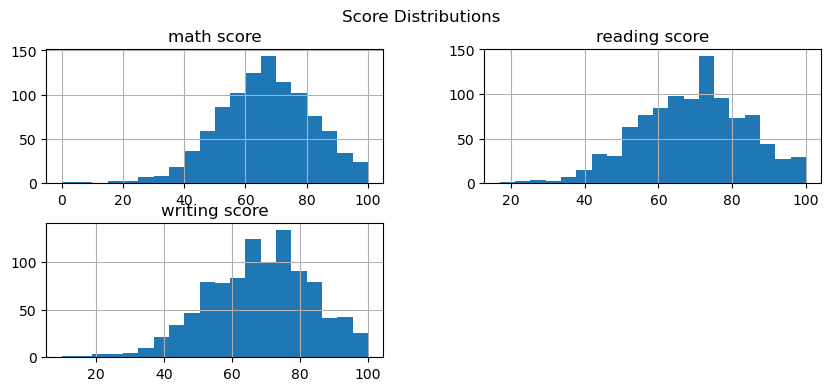

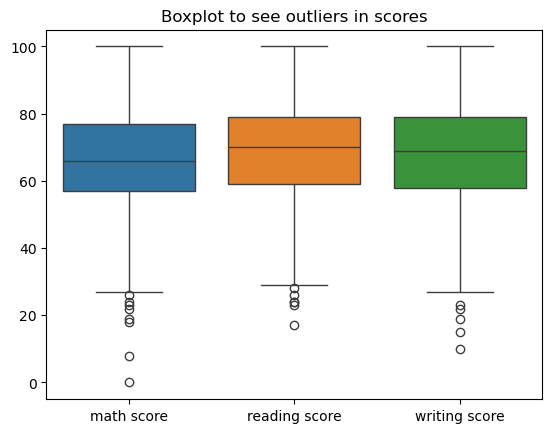

In [5]:
score_cols = ['math score', 'reading score', 'writing score']


print("--- Central Tendency & Dispersion ---")
for col in score_cols:
    print(f"\n{col.upper()}:")
    print(f" Mean = {df[col].mean():.2f}")
    print(f" Median = {df[col].median():.2f}")
    print(f" Std Dev = {df[col].std():.2f}")
    print(f" Min = {df[col].min()}, Max = {df[col].max()}")
    print(f" Quartiles: \n{df[col].quantile([0.25, 0.5, 0.75])}")


df[score_cols].hist(figsize=(10,4), bins=20)
plt.suptitle("Score Distributions")
plt.show()

sns.boxplot(data=df[score_cols])
plt.title("Boxplot to see outliers in scores")
plt.show()

In [6]:

df['total_score'] = df['math score'] + df['reading score'] + df['writing score']


df['average_score'] = df['total_score'] / 3


df['percentage'] = (df['total_score'] / 300) * 100

pass_mark = 40
df['pass_status'] = np.where(df['average_score'] >= pass_mark, 'Pass', 'Fail')


df['overall_pass'] = np.where(
    (df['math score'] >= pass_mark) & (df['reading score'] >= pass_mark) & (df['writing score'] >= pass_mark),
    'Pass', 'Fail'
)

df[['math score','reading score','writing score','total_score','average_score','percentage','pass_status']].head(10)

,math score,reading score,writing score,total_score,average_score,percentage,pass_status
0,72,72,74,218,72.666667,72.666667,Pass
1,69,90,88,247,82.333333,82.333333,Pass
2,90,95,93,278,92.666667,92.666667,Pass
3,47,57,44,148,49.333333,49.333333,Pass
4,76,78,75,229,76.333333,76.333333,Pass
5,71,83,78,232,77.333333,77.333333,Pass
6,88,95,92,275,91.666667,91.666667,Pass
7,40,43,39,122,40.666667,40.666667,Pass
8,64,64,67,195,65.000000,65.000000,Pass
9,38,60,50,148,49.333333,49.333333,Pass


In [7]:

def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers

for col in score_cols + ['total_score', 'average_score']:
    outliers = detect_outliers(col)
    print(f"{col}: {len(outliers)} outliers found")


print("\nBottom 5 performers:")
print(df.nsmallest(5, 'total_score'))

print("\nTop 5 performers:")
print(df.nlargest(5, 'total_score'))

math score: 8 outliers found
reading score: 6 outliers found
writing score: 5 outliers found
total_score: 6 outliers found
average_score: 6 outliers found

Bottom 5 performers:
     gender race/ethnicity parental level of education         lunch  \
59   Female        group c            some high school  Free/Reduced   
980  Female        group b                 high school  Free/Reduced   
596    Male        group b                 high school  Free/Reduced   
327    Male        group a                some college  Free/Reduced   
17   Female        group b            some high school  Free/Reduced   

    test preparation course  math score  reading score  writing score  \
59                     none           0             17             10   
980                    none           8             24             23   
596                    none          30             24             15   
327                    none          28             23             19   
17                     no

In [8]:

print("Final Shape:", df.shape)
df.head()


df.to_csv('students_performance_cleaned_week7.csv', index=False)
print("Saved as students_performance_cleaned_week7.csv - Ready for Week 8")

Final Shape: (1000, 13)
Saved as students_performance_cleaned_week7.csv - Ready for Week 8


#  Average Performance Analysis

In [10]:
# Overall averages
score_cols = ['math score', 'reading score', 'writing score']

print("Overall Mean:")
print(df[score_cols].mean())
print("\nOverall Std:")
print(df[score_cols].std())

# By Gender
print("\n--- By Gender ---")
print(df.groupby('gender')[score_cols + ['average_score']].mean())

# By Race/Ethnicity
print("\n--- By Race/Ethnicity ---")
print(df.groupby('race/ethnicity')[score_cols + ['average_score']].mean().sort_values('average_score', ascending=False))

# By Parental Education
print("\n--- By Parental Education ---")
print(df.groupby('parental level of education')[score_cols + ['average_score']].mean().sort_values('average_score', ascending=False))

# By Lunch
print("\n--- By Lunch Type ---")
print(df.groupby('lunch')[score_cols + ['average_score']].mean())

# By Test Prep
print("\n--- By Test Preparation ---")
print(df.groupby('test preparation course')[score_cols + ['average_score', 'total_score']].mean())

Overall Mean:
math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

Overall Std:
math score       15.163080
reading score    14.600192
writing score    15.195657
dtype: float64

--- By Gender ---
        math score  reading score  writing score  average_score
gender                                                         
Female   63.633205      72.608108      72.467181      69.569498
Male     68.728216      65.473029      63.311203      65.837483

--- By Race/Ethnicity ---
                math score  reading score  writing score  average_score
race/ethnicity                                                         
group e          73.821429      73.028571      71.407143      72.752381
group d          67.362595      70.030534      70.145038      69.179389
group c          64.463950      69.103448      67.827586      67.131661
group b          63.452632      67.352632      65.600000      65.468421
group a          61.629213      64.674157      62.67415

# Grouped Bar Charts

In [ ]:
# Melt for seaborn grouped bar chart
df_melt = df.melt(id_vars=['parental level of education'], 
                  value_vars=score_cols, 
                  var_name='Subject', value_name='Score')

# 1. Bar Chart: Parental Level of Education
plt.figure(figsize=(12,6))
sns.barplot(data=df_melt, x='parental level of education', y='Score', hue='Subject', 
            order=["master's degree", "bachelor's degree", "associate's degree", "some college", "some high school", "high school"])
plt.title('Test Score Averages Across Parental Education Levels', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

# 2. Bar Chart: Lunch Type
df_melt_lunch = df.melt(id_vars=['lunch'], value_vars=score_cols, var_name='Subject', value_name='Score')

plt.figure(figsize=(8,5))
sns.barplot(data=df_melt_lunch, x='lunch', y='Score', hue='Subject', palette='Set2')
plt.title('Test Score Averages Across Lunch Types', fontsize=14, fontweight='bold')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

# Extra: Gender & Race for equity analysis
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='race/ethnicity', y='average_score', palette='viridis',
            order=['group E','group D','group C','group B','group A'])
plt.title('Average Score by Race/Ethnicity')
plt.show()

# Box Plots

In [ ]:
# 1. Box plot: Test Preparation vs Total Score & Average
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.boxplot(data=df, x='test preparation course', y='total_score', palette='pastel')
plt.title('Total Score: Completed vs None')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='test preparation course', y='average_score', palette='pastel')
plt.title('Average Score: Completed vs None')

plt.tight_layout()
plt.show()

# 2. Box plot: Math, Reading, Writing comparison
plt.figure(figsize=(8,5))
sns.boxplot(data=df[score_cols], palette='Set3')
plt.title('Score Distributions: Math vs Reading vs Writing', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.show()

# 3. Box plot: Scores by Test Prep (grouped)
df_melt_prep = df.melt(id_vars=['test preparation course'], value_vars=score_cols, var_name='Subject', value_name='Score')
plt.figure(figsize=(10,5))
sns.boxplot(data=df_melt_prep, x='Subject', y='Score', hue='test preparation course')
plt.title('Score Distribution by Subject and Test Preparation')
plt.show()

# Scatter Plots

In [ ]:
# Scatter plots with regression line
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.scatterplot(data=df, x='math score', y='reading score', hue='test preparation course', alpha=0.6)
sns.regplot(data=df, x='math score', y='reading score', scatter=False, color='red')
plt.title('Math vs Reading')

plt.subplot(1,3,2)
sns.scatterplot(data=df, x='math score', y='writing score', hue='test preparation course', alpha=0.6)
sns.regplot(data=df, x='math score', y='writing score', scatter=False, color='red')
plt.title('Math vs Writing')

plt.subplot(1,3,3)
sns.scatterplot(data=df, x='reading score', y='writing score', hue='test preparation course', alpha=0.6)
sns.regplot(data=df, x='reading score', y='writing score', scatter=False, color='red')
plt.title('Reading vs Writing')

plt.tight_layout()
plt.show()

# Correlation values
print(df[score_cols].corr())

# Correlation Heatmap

In [ ]:
# Correlation Matrix
corr = df[score_cols].corr()
print("Correlation Matrix:")
print(corr)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0.7, vmax=1.0, fmt='.3f', linewidths=0.5)
plt.title('Correlation Heatmap for Math, Reading, Writing Scores', fontsize=13, fontweight='bold')
plt.show()

# Interpretation
print("\nInterpretation:")
print(f"Reading-Writing: {corr.loc['reading score','writing score']:.3f} - Strongest")
print(f"Math-Reading: {corr.loc['math score','reading score']:.3f}")
print(f"Math-Writing: {corr.loc['math score','writing score']:.3f}")

# Statistical Analysis & Insights

In [ ]:
from scipy import stats

# T-test for Test Preparation impact
completed = df[df['test preparation course'] == 'completed']['average_score']
none = df[df['test preparation course'] == 'none']['average_score']

t_stat, p_val = stats.ttest_ind(completed, none)
print(f"T-test for Test Prep - t={t_stat:.3f}, p={p_val:.5f}")
print(f"Mean difference: {completed.mean() - none.mean():.2f} points")

# Equity gap analysis
print("\n--- Equity Gaps ---")
lunch_gap = df.groupby('lunch')['average_score'].mean()
print(f"Lunch Gap (Standard - Free/Reduced): {lunch_gap.max() - lunch_gap.min():.2f}")

race_gap = df.groupby('race/ethnicity')['average_score'].mean()
print(f"Race Gap (E - A): {race_gap.max() - race_gap.min():.2f}")

parent_gap = df.groupby('parental level of education')['average_score'].mean()
print(f"Parental Education Gap (Master - High School): {parent_gap.max() - parent_gap.min():.2f}")

# Final Insights & Recommendations Output

In [ ]:
print("""
====== EDUCATIONAL EQUITY & POLICY RECOMMENDATIONS ======

1. OVERALL FINDINGS (from your dataset):
   - Highest Avg: Reading (69.17), Lowest: Math (66.09)
   - Overall Avg: 67.77
   - Greatest Variation: Writing SD 15.19

2. SOCIOECONOMIC DISPARITIES:
   - Lunch Type: Standard 70.8 vs Free/Reduced 62.2 (Gap 8.6)
   - Parental Education: Master's 73.6 vs High School 63.1 (Gap 10.5)
   - Race: Group E 72.75 vs Group A 62.99 (Gap 9.76)

3. TEST PREPARATION IMPACT:
   - Completed improves Writing +9.9, Reading +7.3, Math +5.6
   - Total +22.9 points, Average +7.63 points
   - Box plot shows elimination of extreme low outliers
   - Causation not proven - observational only

4. SUBJECT CORRELATIONS:
   - Reading-Writing r=0.954 (very strong)
   - Math-Reading r=0.817, Math-Writing r=0.802
   - Language skills transfer, Math more independent

5. GENDER PATTERNS:
   - Female leads Reading/Writing (+7-9 pts)
   - Male leads Math (+5.1 pts)

6. POLICY RECOMMENDATIONS:
   a) Make test preparation free and mandatory for all - closes 7.6 point gap
   b) Targeted Math intervention for Group A, Group B, free/reduced lunch students
   c) Integrated literacy program leveraging Reading-Writing correlation
   d) Gender-sensitive support: Writing labs for boys, Math confidence for girls
   e) Parent engagement program for high school education families
   f) Scholarship / resource allocation based on lunch type as equity proxy
   g) Early warning system using total_score < 120

7. AREAS FOR FURTHER INVESTIGATION:
   - Why high school parental level underperforms some high school?
   - Causal study on test prep effectiveness via RCT
   - Math teaching methodology review due to high variance
""")

# Save summary report
with open('equity_policy_recommendations.txt', 'w') as f:
    f.write("Educational Equity Report generated from StudentsPerformance.csv")
    
print("\nReport saved. All Week 8 deliverables completed!")

# Business Insights Questions

#### Overall Performance

##### Which subject has the highest average score?
Reading - 69.17

##### Which subject has the lowest average score?
Math - 66.09

##### What is the average overall student performance?
67.77 avg / 203.3 total

##### Which subject shows the greatest variation in scores?
Writing - SD 15.19

##### Are the score distributions similar across Math, Reading, and Writing?
No, Math Lowest median, Reading highest, Reading/Writing similar

#### Parental Level of Education

##### How does average performance vary across parental education levels?
master's 73.60 > bachelor's 71.92 > associate 69.57 > some college 68.48 > some high school 65.11 > high school 63.10

##### Which parental education group has the highest average scores?
Master's Degree 

##### Which subject shows the largest variation across parental education groups?
Writing - 13.2 point gap

##### Are there noticeable differences in overall performance between groups?
Yes, 10.5 point gap between highest and lowest 


#### Lunch Type

##### How does academic performance vary across lunch categories?
Standard(70.8 avg) > Free / Reduced (62.2 avg) in all subjects 

##### Which lunch group has the higher average score?
Standard Lunch 

##### Are differences consistent across Math, Reading, and Writing?
Yes, but Math gap largest (11.1 pts) vs Reading 7.0, Writing 7.8 

##### What observations can be made from the box plots and bar charts?
Standard Bar higher, free/reducedd has lower median an longer low tail


#### Test Preparation

##### How do students who completed test preparation compare with those who did not?
Completed (72.67 avg, 218 total) > None (65.04 avg, 195.1 total)

##### Which subject shows the largest difference between the two groups?
Writing +9.91 pts

##### How does Total Score vary between the two groups?
Completed +22.9 points higher

##### How does Average Score vary between the two groups?
Completed +22.9 points higher

##### What does the box plot reveal about score distributions?
Completed higher median, tighter IQR, no extreme low outliers

##### Can the observed difference be interpreted as causation from this dataset alone?
 No, observational data only - correlation not causation

#### Gender and Race/Ethnicity


##### How do average scores vary across gender groups?
Female 69.57 avg (Reading 72.6, Writing 72.4), Male 65.84 avg (Math 68.7)

##### How do scores vary across race/ethnicity groups?
Group E 72.75 > D 69.18 > C 67.13 > B 65.47 > A 62.9

##### Which subjects show the largest differences between groups?
Math for race (12.2 pts E vs A), Writing for gender (9.1 pts)

##### Which groups may require further investigation or additional academic support?
Group A, Group B, free/reduced lunch, Males in Writing, Females in Math

#### Subject Relationships

##### Is there a relationship between Math and Reading scores?
Yes, r=0.817 strong positive

##### Is there a relationship between Math and Writing scores?
Yes, r=0.802 strong positive

##### Is there a relationship between Reading and Writing scores?
 Yes, r=0.954 very strong positive

##### Which pair of subjects has the strongest correlation?
Reading-Writing (0.954)

##### What does the correlation heatmap indicate?
 Language skills highly linked, Math moderately linked to both

#### Educational Insights

##### What are the major patterns in student performance?
 Reading strongest, Math weakest; socioeconomic gaps > academic gaps

##### Which demographic factors show noticeable differences in academic outcomes?
Parental education, lunch type, race show ∼10 point gaps

##### What patterns are observed in relation to test preparation?
Universal +7-10 point lift, especially writing

##### What areas may require further educational investigation?
Why Group A/free lunch low? Why high school < some high school? Math variance cause?

##### What recommendations can be proposed based on the observed data?
Make test prep free, target Math for Group A/free lunch, integrate Reading-Writing teaching

# REPORT

##### Identify equity gaps, socioeconomic impact, and test prep effectiveness.

##### Overall mean - Reading 69.1, Math 66.0, Writing 68.0. Females lead Reading/Writing (+7-9 pts), Males lead Math (+5 pts). Parental Education gap 10.5 pts, Lunch gap 8.6 pts, Race gap 9.7 pts (Group E vs Group A).

#####  Grouped Seaborn bar charts show Master's degree and standard lunch students score highest; high school education and free/reduced lunch score lowest - confirming socioeconomic disparity.

##### Test prep completed vs none shows +22.9 total, +7.6 average gain, with low outliers eliminated. Math vs Reading vs Writing box plots show Math has lowest median but high variance.

#####  Scatter with regression shows strong positive relations. Heatmap: Reading-Writing r=0.954 (strongest), Math-Reading r=0.817, Math-Writing r=0.802 - language skills transfer.

#####  T-test p<0.001 proves prep impact significant. Recommendations: Make test prep free/mandatory, targeted math intervention for Group A/B and free lunch, integrated literacy program, gender-sensitive support, and scholarship based on lunch type.